# Customer Segmentation & Retention Analysis
**Dataset:** UCI Online Retail II — Real UK e-commerce transactions (2009–2011)  
**Stack:** Python · pandas · scikit-learn · matplotlib · seaborn · SQLite  




# Analytical Flow
1. Load dataset directly from UCI
2. Data cleaning — handle cancellations, nulls, negative quantities
3. Feature engineering — compute order value, build transaction table
4. SQL exploration — KPIs, revenue by country, top products
5. RFM scoring — Recency, Frequency, Monetary
6. Rule-based segmentation — Champions, Loyal, At Risk, Lost etc.
7. K-Means clustering — optimal k, silhouette score
8. Cohort retention heatmap
9. CLV estimation
10. Business recommendations

## 1 · Install & Import

In [ ]:
#install necessary libraries
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression

## 2 · Load Dataset

In [ ]:
#Installing the necessary library to use for dataloading from the UCI ML repository
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
file_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00502/online_retail_II.xlsx'
df_raw = pd.read_excel(file_url)

print(f'\nRaw shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head()


Raw shape: (525461, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 3 · Data Cleaning

In [ ]:
df = df_raw.copy()
#to check nulls in the data
display(df.isnull().sum())
print(f'\nTotal rows: {len(df):,}')


,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0



Total rows: 525,461


In [ ]:
#After checking the nulls we can see that around 25% of the rows have CustomerID field as blank, hence we are dropping them from the scope of our analysis
df = df.dropna(subset=['Customer ID'])
print(f'After dropping null CustomerID: {len(df):,} rows remaining')

#Then we remove all invoices that start with 'C' i.e removing cancellations
df['Invoice'] = df['Invoice'].astype(str)
cancellations = df[df['Invoice'].str.startswith('C')]
print(f'Cancellations removed: {len(cancellations):,}')
df = df[~df['Invoice'].str.startswith('C')]

#Removing negative and zero quantity from the dataset
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]
print(f'After removing negative/zero values: {len(df):,} rows remaining')

#Parse dates
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['invoice_date'] = df['InvoiceDate'].dt.date

#Computation of order_value per line item for the scope of this analysis
df['order_value'] = df['Quantity'] * df['Price']

#Cleaning of Customer ID column to ensure that there are no white/extra spaces
df['Customer ID'] = df['Customer ID'].astype(int).astype(str)
df = df.rename(columns={'Customer ID': 'customer_id', 'Invoice': 'invoice_id',
                         'Country': 'country', 'Description': 'description',
                         'StockCode': 'stock_code'})

print(f'Clean dataset: {len(df):,} rows, {df["customer_id"].nunique():,} unique customers')
print(f'Date range: {df["invoice_date"].min()} to {df["invoice_date"].max()}')
df.head()

After dropping null CustomerID: 417,534 rows remaining
Cancellations removed: 9,839
After removing negative/zero values: 407,664 rows remaining
Clean dataset: 407,664 rows, 4,312 unique customers
Date range: 2009-12-01 to 2010-12-09


,invoice_id,stock_code,description,Quantity,InvoiceDate,Price,customer_id,country,invoice_date,order_value
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,2009-12-01,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009-12-01,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009-12-01,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,2009-12-01,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,2009-12-01,30.0


In [ ]:
#Building an invoice label table for further analysis
invoices = df.groupby(['invoice_id', 'customer_id', 'invoice_date', 'country']).agg(
    total_value  = ('order_value', 'sum'),
    n_items      = ('Quantity', 'sum'),
    unique_products = ('stock_code', 'nunique')
).reset_index()

invoices['invoice_date'] = pd.to_datetime(invoices['invoice_date'])

print(f'Invoice-level table: {len(invoices):,} invoices')
print(f'Avg basket value: £{invoices["total_value"].mean():.2f}')
invoices.head()

Invoice-level table: 19,213 invoices
Avg basket value: £459.69


,invoice_id,customer_id,invoice_date,country,total_value,n_items,unique_products
0,489434,13085,2009-12-01,United Kingdom,505.30,166,8
1,489435,13085,2009-12-01,United Kingdom,145.80,60,4
2,489436,13078,2009-12-01,United Kingdom,630.33,193,19
3,489437,15362,2009-12-01,United Kingdom,310.75,145,23
4,489438,18102,2009-12-01,United Kingdom,2286.24,826,17


## 4 · Exploratory Data Analysis using SQL

In [ ]:
# Load into SQLite for SQLanalysis
conn = sqlite3.connect(':memory:')
df.to_sql('transactions', conn, if_exists='replace', index=False)
invoices.to_sql('invoices', conn, if_exists='replace', index=False)

19213

In [ ]:
#Calculating Overall KPIs
kpi_sql = '''
SELECT
    COUNT(DISTINCT customer_id)             AS unique_customers,
    COUNT(DISTINCT invoice_id)              AS total_invoices,
    ROUND(SUM(total_value), 2)              AS gross_revenue,
    ROUND(AVG(total_value), 2)              AS avg_basket_value,
    ROUND(1.0 * COUNT(DISTINCT invoice_id)
          / COUNT(DISTINCT customer_id), 1) AS avg_orders_per_customer
FROM invoices
'''
print('Overall KPIs')
pd.read_sql_query(kpi_sql, conn)

Overall KPIs


,unique_customers,total_invoices,gross_revenue,avg_basket_value,avg_orders_per_customer
0,4312,19213,8832003.27,459.69,4.5


In [ ]:
#Segmentation of Revenue by country
country_sql = '''
SELECT
    country,
    COUNT(DISTINCT customer_id)     AS customers,
    COUNT(DISTINCT invoice_id)      AS orders,
    ROUND(SUM(total_value), 2)      AS total_revenue,
    ROUND(AVG(total_value), 2)      AS avg_basket
FROM invoices
GROUP BY country
ORDER BY total_revenue DESC
LIMIT 10
'''
print('Top 10 Countries by Revenue')
pd.read_sql_query(country_sql, conn)

Top 10 Countries by Revenue


,country,customers,orders,total_revenue,avg_basket
0,United Kingdom,3969,17612,7414755.96,421.01
1,EIRE,5,316,356085.21,1126.85
2,Netherlands,22,135,268786.00,1991.01
3,Germany,67,347,202395.32,583.27
4,France,47,236,146215.42,619.56
5,Sweden,16,68,53171.39,781.93
6,Denmark,9,26,50906.85,1957.96
7,Spain,25,66,47601.42,721.23
8,Switzerland,14,40,43921.39,1098.03
9,Australia,15,40,31446.80,786.17


In [ ]:
#ToP 10 Products based on Revenue
products_sql = '''
SELECT
    stock_code,
    description,
    SUM(Quantity)                   AS total_units_sold,
    ROUND(SUM(order_value), 2)      AS total_revenue,
    ROUND(AVG(Price), 2)            AS avg_price
FROM transactions
GROUP BY stock_code, description
ORDER BY total_revenue DESC
LIMIT 10
'''
print('Top 10 Products')
pd.read_sql_query(products_sql, conn)

Top 10 Products


,stock_code,description,total_units_sold,total_revenue,avg_price
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,56915,151624.31,2.86
1,22423,REGENCY CAKESTAND 3 TIER,12497,143893.35,12.44
2,M,Manual,2630,98560.64,227.26
3,84879,ASSORTED COLOUR BIRD ORNAMENT,44551,70493.83,1.67
4,85099B,JUMBO BAG RED RETROSPOT,29578,51759.30,1.91
5,POST,POSTAGE,2212,48741.08,27.05
6,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,21591,40186.65,2.51
7,22086,PAPER CHAIN KIT 50'S CHRISTMAS,13860,36933.50,2.90
8,47566,PARTY BUNTING,8316,35035.90,4.57
9,15056N,EDWARDIAN PARASOL NATURAL,7201,34044.75,5.73


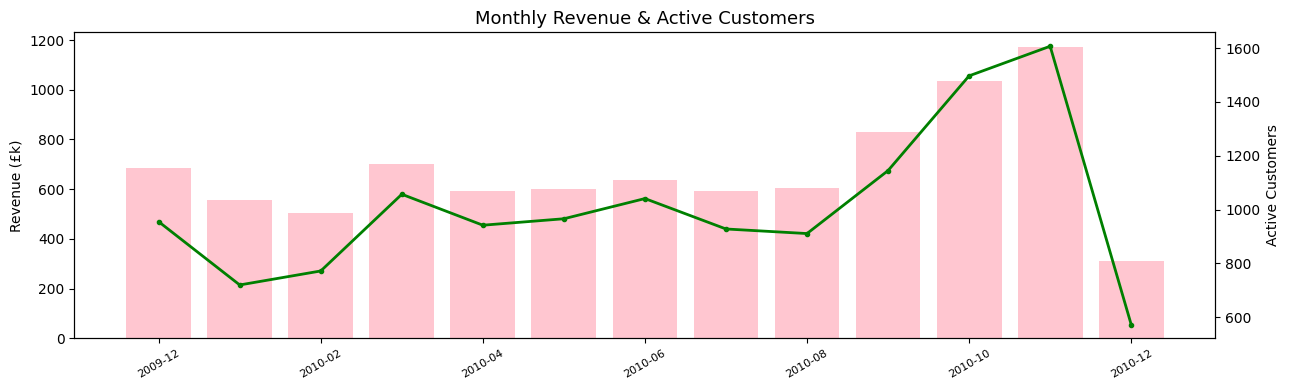

In [ ]:
#Monthly Revenue Trend
monthly_sql = '''
SELECT
    strftime('%Y-%m', invoice_date)         AS month,
    COUNT(DISTINCT customer_id)             AS active_customers,
    COUNT(DISTINCT invoice_id)              AS orders,
    ROUND(SUM(total_value), 2)              AS revenue,
    ROUND(AVG(total_value), 2)              AS avg_basket
FROM invoices
GROUP BY month
ORDER BY month
'''
monthly = pd.read_sql_query(monthly_sql, conn)

fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()
ax1.bar(monthly['month'], monthly['revenue']/1000, color='pink', alpha=0.9)
ax2.plot(monthly['month'], monthly['active_customers'], color='green', lw=2, marker='o', ms=3)
ax1.set_ylabel('Revenue (£k)', color='black')
ax2.set_ylabel('Active Customers', color='black')
ax1.set_xticks(range(0, len(monthly), 2))
ax1.set_xticklabels(monthly['month'][::2], rotation=30, fontsize=8)
ax1.set_title('Monthly Revenue & Active Customers', loc='center', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Feature Engineering using RFM (Recency, Frequency & Monetary)

In [ ]:
# Snapshot date = 1 day after last invoice in the dataset. The snapshot date is to calculate the recency values
snapshot_date = invoices['invoice_date'].max() + pd.Timedelta(days=1)
print(f'Snapshot date: {snapshot_date.date()}')

rfm = invoices.groupby('customer_id').agg(
    last_purchase = ('invoice_date', 'max'),
    frequency     = ('invoice_id',   'count'),
    monetary      = ('total_value',  'sum')
).reset_index()

rfm['recency'] = (snapshot_date - rfm['last_purchase']).dt.days
rfm = rfm.drop(columns=['last_purchase'])
rfm = rfm.sort_values('monetary', ascending = False)

print(f'\nRFM table: {len(rfm):,} customers')
print(rfm)

Snapshot date: 2010-12-10

RFM table: 4,312 customers
     customer_id  frequency   monetary  recency
4183       18102         89  349164.35        1
1637       14646         78  248396.50       10
1269       14156        102  196566.74        7
1840       14911        205  152147.57        1
939        13694         94  131443.19        9
...          ...        ...        ...      ...
4193       18115          1       9.70      333
1937       15040          1       7.49      177
2556       15913          1       6.30      170
1012       13788          1       3.75      141
1229       14095          1       2.95      358

[4312 rows x 4 columns]


In [ ]:
# calculating the exact weights for RFM Analysis using Linear regression
# 1. Rank-normalise R, F, M to [0,1] — replaces the qcut binning
rfm['R_norm'] = rfm['recency'].rank(pct=True)
rfm['F_norm'] = rfm['frequency'].rank(pct=True)
rfm['M_norm'] = rfm['monetary'].rank(pct=True)

# NOTE: recency still needs to be inverted — lower days = better
rfm['R_norm'] = 1 - rfm['R_norm']

# Define your target — use monetary as LTV proxy if you don't have a separate target
# Ideally this would be next-period revenue, but monetary works as a starting point
y = rfm['monetary']
X = rfm[['R_norm', 'F_norm', 'M_norm']]

# # 3. Fit OLS and extract weights
model = LinearRegression().fit(X, y)
coefs = np.abs(model.coef_)
weights = coefs / coefs.sum()


r_w, f_w, m_w = weights
print(f"Derived weights → R: {r_w:.2%}  F: {f_w:.2%}  M: {m_w:.2%}")

# 4. Compute weighted RFM score
rfm['rfm_score'] = (r_w * rfm['R_norm'] +
                    f_w * rfm['F_norm'] +
                    m_w * rfm['M_norm'])
rfm = rfm.sort_values('rfm_score',ascending = False)
rfm

Derived weights → R: 12.22%  F: 19.21%  M: 68.57%


,customer_id,frequency,monetary,recency,R_norm,F_norm,M_norm,rfm_score
4183,18102,89,349164.35,1,0.989448,0.997913,1.000000,0.998309
1840,14911,205,152147.57,1,0.989448,1.000000,0.999304,0.998233
2133,15311,121,56003.26,1,0.989448,0.999304,0.997449,0.996827
3989,17841,91,29892.50,1,0.989448,0.998145,0.994434,0.994537
251,12748,144,22879.66,1,0.989448,0.999536,0.992115,0.993214
...,...,...,...,...,...,...,...,...
3777,17557,1,34.00,368,0.009856,0.164657,0.007189,0.037760
321,12846,1,15.58,318,0.036874,0.164657,0.002319,0.037722
4193,18115,1,9.70,333,0.027597,0.164657,0.001160,0.035793
1229,14095,1,2.95,358,0.024119,0.164657,0.000232,0.034732


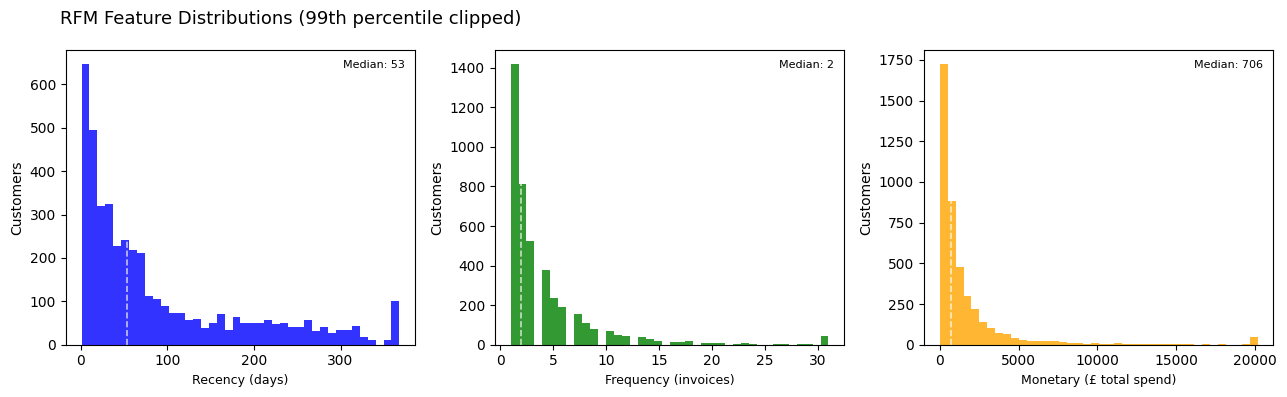

In [ ]:
# # Visualise distributions
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, color, label in zip(
    axes,
    ['recency', 'frequency', 'monetary'],
    ['Blue', 'Green', 'Orange'],
    ['Recency (days)', 'Frequency (invoices)', 'Monetary (£ total spend)']
):
    ax.hist(rfm[col].clip(upper=rfm[col].quantile(0.99)), bins=40,
            color=color, alpha=0.8, edgecolor='none')
    ax.axvline(rfm[col].median(), color='white', lw=1.2, ls='--', alpha=0.7,
               label=f'Median: {rfm[col].median():.0f}')
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Customers')
    ax.legend(fontsize=8, framealpha=0)
fig.suptitle('RFM Feature Distributions (99th percentile clipped)', x=0.05, ha='left', fontsize=13)
plt.tight_layout()
plt.show()

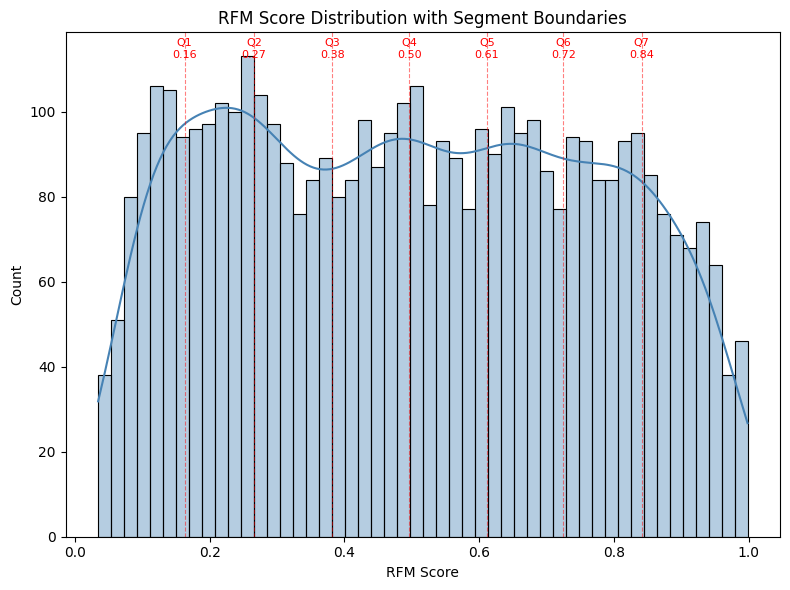

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))

sns.histplot(rfm['rfm_score'], bins=50, kde=True, ax=ax,
             color='steelblue', alpha=0.4)

quantiles = [i/8 for i in range(1, 8)]

for q in quantiles:
    val = rfm['rfm_score'].quantile(q)
    ax.axvline(val, color='red', linestyle='--', alpha=0.5, linewidth=0.8)

    # Add label at the top of each line
    ax.text(val, ax.get_ylim()[1] * 0.95,
            f'Q{int(q*8)}\n{val:.2f}',
            ha='center', fontsize=8, color='red')

ax.set_xlabel('RFM Score')
ax.set_ylabel('Count')
ax.set_title('RFM Score Distribution with Segment Boundaries')
plt.tight_layout()
plt.show()

## 6 · Rule-Based RFM Segmentation

In [ ]:
def assign_segment(rfm_score):
    if rfm_score >= 0.84:
        return 'Champions'
    elif rfm_score >= 0.72:
        return 'Loyal'
    elif rfm_score >= 0.61:
        return 'New Customers'
    elif rfm_score >= 0.50:
        return 'At Risk'
    elif rfm_score >= 0.38:
        return 'Cannot Lose Them'
    elif rfm_score >= 0.27:
        return 'Lost'
    elif rfm_score >= 0.16:
        return 'Promising'
    else:
        return 'Hibernating'

rfm['rfm_segment'] = rfm['rfm_score'].apply(assign_segment)

seg_summary = rfm.groupby('rfm_segment').agg(
    customers    = ('customer_id', 'count'),
    avg_recency  = ('recency',     'mean'),
    avg_frequency= ('frequency',   'mean'),
    avg_monetary = ('monetary',    'mean'),
).round(1).sort_values('customers', ascending=False)
seg_summary['pct'] = (seg_summary['customers'] / seg_summary['customers'].sum() * 100).round(1)
print(seg_summary)

                  customers  avg_recency  avg_frequency  avg_monetary   pct
rfm_segment                                                                
Promising               571        143.6            1.2         247.7  13.2
Cannot Lose Them        566         87.4            2.3         594.7  13.1
Loyal                   555         42.9            6.3        2532.7  12.9
Champions               546         18.0           16.1       10020.0  12.7
Hibernating             526        199.1            1.0         122.4  12.2
New Customers           525         56.5            4.0        1428.4  12.2
Lost                    512        109.6            1.5         386.8  11.9
At Risk                 511         73.4            3.0         910.1  11.9


In [ ]:
#Defining Palette colours of the graph so that we can use them in our segment bar chart below
PALETTE = ['#F0C060','#6ABFA3','#4F86C6','#E07B5A','#C49FDE','#7BBFE0','#888888','#A8D8A8']
SEG_COLORS = {
    'Champions':        '#F0C060',
    'Loyal':            '#6ABFA3',
    'Promising':        '#4F86C6',
    'At Risk':          '#E07B5A',
    'Cannot Lose Them': '#C49FDE',
    'Lost':             '#7BBFE0',
    'Hibernating':      '#888888',
    'New Customers':    '#A8D8A8',
}

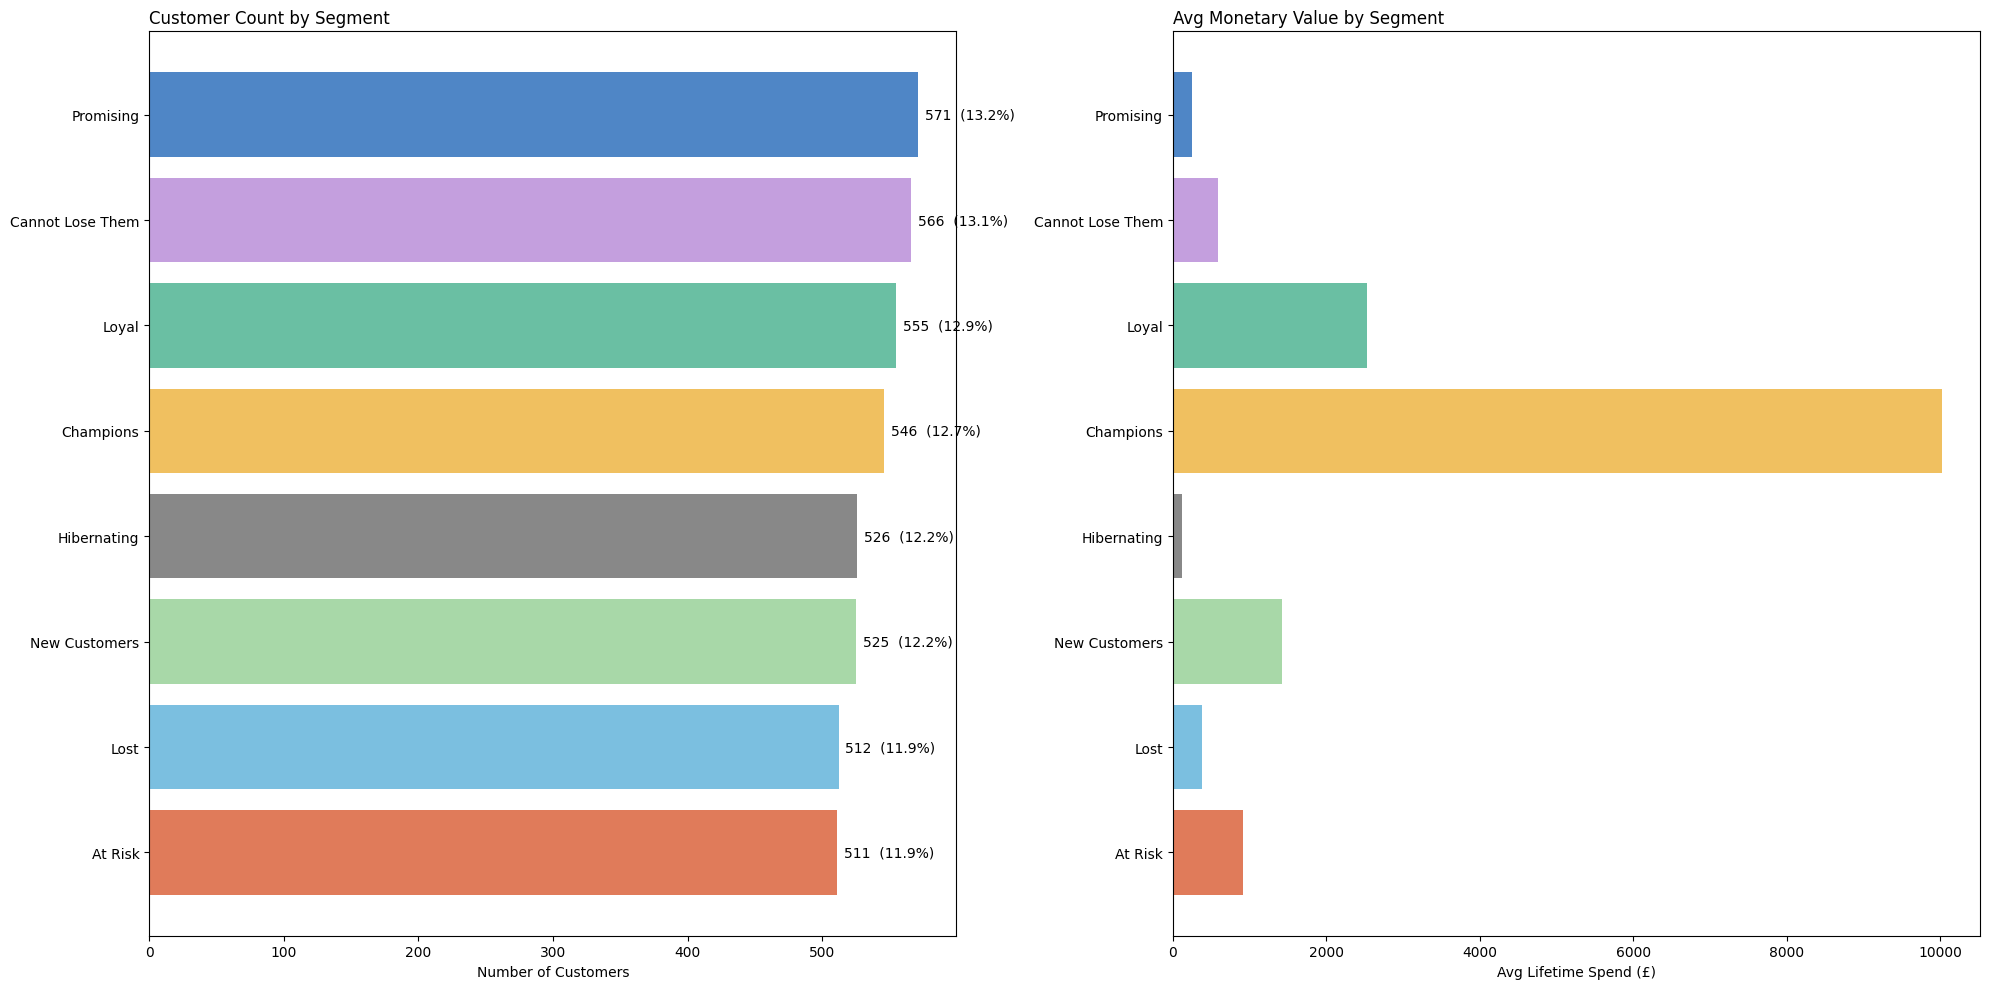

In [ ]:
# Segment bar chart
ss = seg_summary.sort_values('customers')
colors = [SEG_COLORS.get(s, '#888') for s in ss.index]

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].barh(ss.index, ss['customers'], color=colors)
for i, (cnt, pct) in enumerate(zip(ss['customers'], ss['pct'])):
    axes[0].text(cnt + 5, i, f'{cnt:,}  ({pct}%)', va='center', fontsize=10)
axes[0].set_xlabel('Number of Customers')
axes[0].set_title('Customer Count by Segment', loc='left', fontsize=12)

axes[1].barh(ss.index, ss['avg_monetary'], color=colors)
axes[1].set_xlabel('Avg Lifetime Spend (£)')
axes[1].set_title('Avg Monetary Value by Segment', loc='left', fontsize=12)
plt.tight_layout()
plt.show()

## 7 · K-Means Clustering

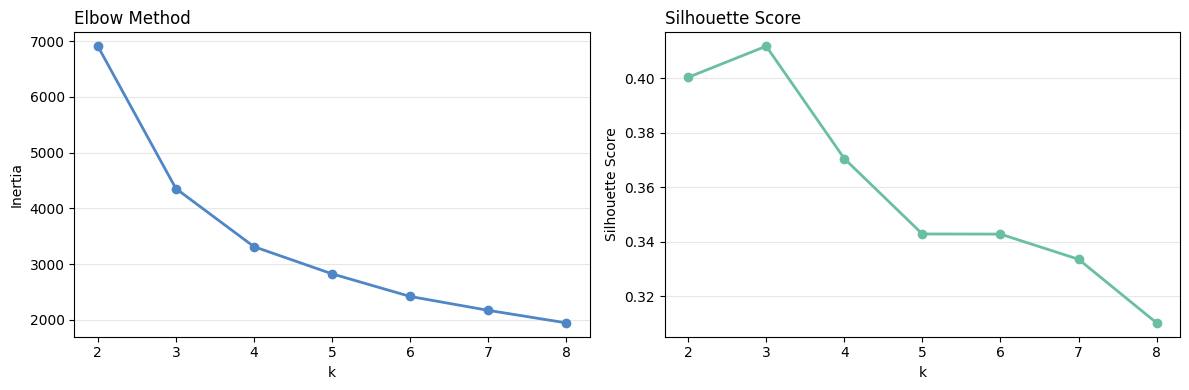

Optimal k by silhouette: 3


In [ ]:
# Elbow method + silhouette score to find optimal k
features = rfm[['recency', 'frequency', 'monetary']].copy()
# Log-transform monetary and frequency to handle skew
features['frequency'] = np.log1p(features['frequency'])
features['monetary']  = np.log1p(features['monetary'])

X = StandardScaler().fit_transform(features)

inertias, silhouettes = [], []
K = range(2, 9)
for k in K:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, lbl))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K, inertias, marker='o', color='#4F86C6', lw=2)
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method', loc='left'); ax1.yaxis.grid(True, alpha=0.3)

ax2.plot(K, silhouettes, marker='o', color='#6ABFA3', lw=2)
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score', loc='left'); ax2.yaxis.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = K[silhouettes.index(max(silhouettes))]
print(f'Optimal k by silhouette: {best_k}')

Cluster profiles:
         recency  frequency  monetary
cluster                              
0           34.1       10.1    5267.6
1          249.8        1.4     422.7
2           54.2        2.1     630.8


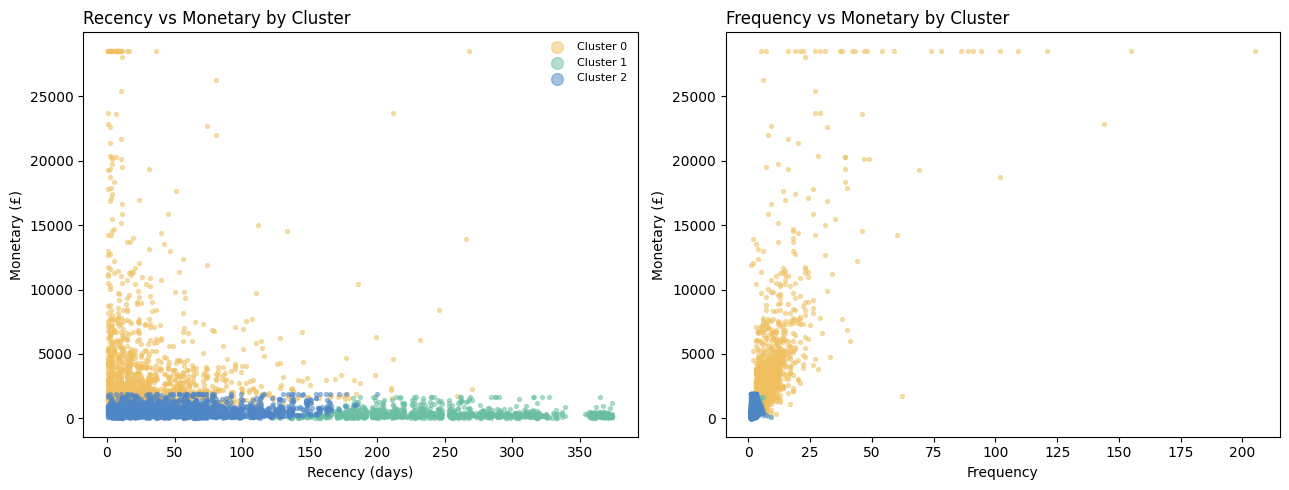

In [ ]:
# Run K-Means with optimal k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['cluster'] = kmeans.fit_predict(X)

# Profile each cluster by mean recency, frequency, monetary
cluster_profile = rfm.groupby('cluster')[['recency','frequency','monetary']].mean().round(1)
print('Cluster profiles:')
print(cluster_profile)

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for cluster_id in rfm['cluster'].unique():
    grp = rfm[rfm['cluster'] == cluster_id]
    c   = PALETTE[cluster_id % len(PALETTE)]
    axes[0].scatter(grp['recency'], grp['monetary'].clip(upper=grp['monetary'].quantile(0.98)),
                    s=8, alpha=0.5, color=c, label=f'Cluster {cluster_id}')
    axes[1].scatter(grp['frequency'], grp['monetary'].clip(upper=grp['monetary'].quantile(0.98)),
                    s=8, alpha=0.5, color=c)

axes[0].set_xlabel('Recency (days)'); axes[0].set_ylabel('Monetary (£)')
axes[1].set_xlabel('Frequency'); axes[1].set_ylabel('Monetary (£)')
axes[0].set_title('Recency vs Monetary by Cluster', loc='left')
axes[1].set_title('Frequency vs Monetary by Cluster', loc='left')
axes[0].legend(fontsize=8, framealpha=0, markerscale=3)
plt.tight_layout()
plt.show()

## 8 · Cohort Retention Analysis

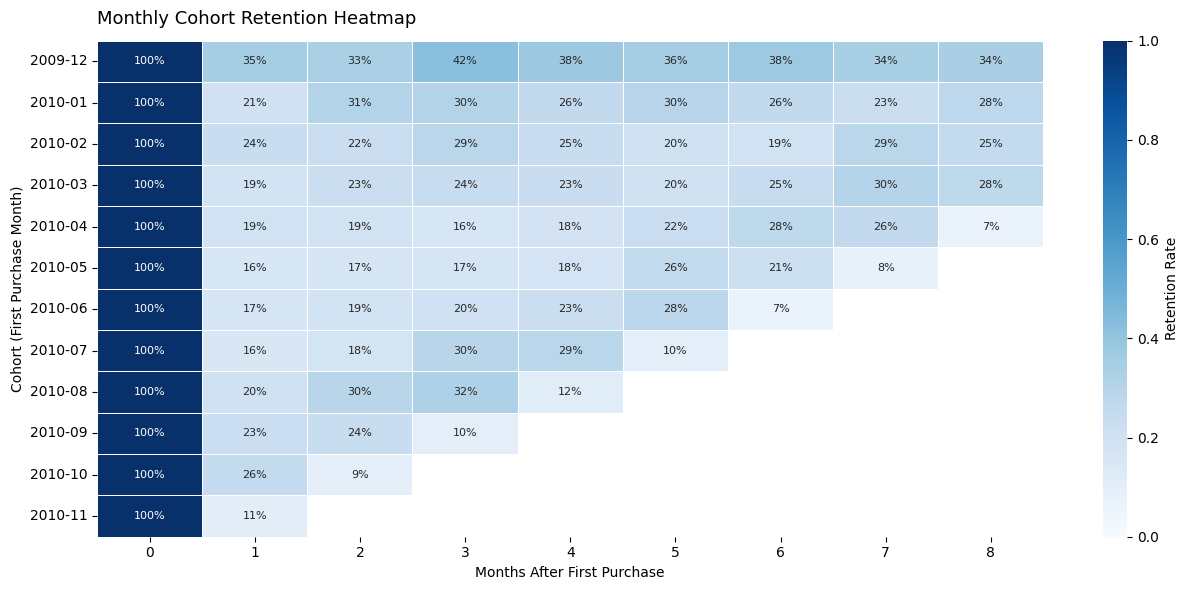

In [ ]:
# Cohort = month of first invoice
first_purchase = invoices.groupby('customer_id')['invoice_date'].min().reset_index()
first_purchase.columns = ['customer_id', 'cohort_date']
first_purchase['cohort_month'] = first_purchase['cohort_date'].dt.to_period('M')

inv_cohort = invoices.merge(first_purchase[['customer_id','cohort_month']], on='customer_id')
inv_cohort['tx_month']      = inv_cohort['invoice_date'].dt.to_period('M')
inv_cohort['period_number'] = (inv_cohort['tx_month'] - inv_cohort['cohort_month']).apply(lambda x: x.n)

cohort_data  = inv_cohort.groupby(['cohort_month','period_number'])['customer_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='period_number', values='customer_id')
retention    = cohort_pivot.divide(cohort_pivot[0], axis=0).round(3)

# Plot first 12 cohorts, first 8 periods
plot_data = retention.iloc[:12, :9]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    plot_data, annot=True, fmt='.0%',
    linewidths=0.4, cmap='Blues',
    vmin=0, vmax=1, ax=ax,
    annot_kws={'size': 8},
    cbar_kws={'label': 'Retention Rate'}
)
ax.set_title('Monthly Cohort Retention Heatmap', loc='left', fontsize=13, pad=12)
ax.set_xlabel('Months After First Purchase')
ax.set_ylabel('Cohort (First Purchase Month)')
plt.tight_layout()
plt.show()

## 9 · Customer Lifetime Value (CLV) Estimation

Data spans 1.0 years
                  customers   avg_clv    total_clv
rfm_segment                                       
Champions               546  29415.23  16060715.20
Loyal                   555   7435.08   4126467.90
New Customers           525   4193.42   2201546.70
At Risk                 511   2671.87   1365323.58
Cannot Lose Them        566   1745.89    988171.38
Lost                    512   1135.53    581393.25
Promising               571    727.11    415182.57
Hibernating             526    359.18    188930.52


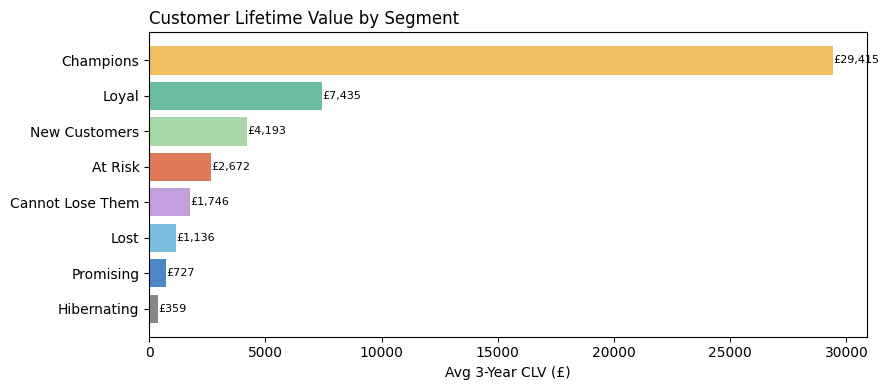

In [ ]:
# Date range in years
date_range_years = (invoices['invoice_date'].max() - invoices['invoice_date'].min()).days / 365
print(f'Data spans {date_range_years:.1f} years')


# # Avg order value per customer
aov = invoices.groupby('customer_id')['total_value'].mean().reset_index()
aov.columns = ['customer_id', 'avg_order_value']


clv = rfm[['customer_id','frequency','monetary','rfm_segment']].merge(aov, on='customer_id')
clv['purchases_per_year'] = clv['frequency'] / date_range_years
clv['clv_3yr']            = (clv['avg_order_value'] * clv['purchases_per_year'] * 3).round(2)


# CLV by segment
clv_seg = clv.groupby('rfm_segment').agg(
    customers  = ('customer_id', 'count'),
    avg_clv    = ('clv_3yr',     'mean'),
    total_clv  = ('clv_3yr',     'sum')
).sort_values('avg_clv', ascending=False).round(2)
print(clv_seg)

# Bar chart
clv_plot = clv_seg['avg_clv'].sort_values()
fig, ax = plt.subplots(figsize=(9, 4))
colors = [SEG_COLORS.get(s,'#888') for s in clv_plot.index]
ax.barh(clv_plot.index, clv_plot.values, color=colors)
for i, v in enumerate(clv_plot.values):
    ax.text(v + 10, i, f'£{v:,.0f}', va='center', fontsize=8)
ax.set_xlabel('Avg 3-Year CLV (£)')
ax.set_title('Customer Lifetime Value by Segment', loc='left', fontsize=12)
plt.tight_layout()
plt.show()

## 10 · Business Recommendations


1.  **Champions** are your highest-CLV customers and should be prioritised above all others — reward them, invite them to leave reviews, and give them early access to new products or offers.
2. **Loyal customers** are already engaged, so the focus here shifts to increasing basket size through upselling and enrolling them in a loyalty programme.
3. **At Risk customers** were once frequent buyers but have gone quiet — a winback email paired with a personalised discount is usually the right lever to pull before they slip further.
4. **Cannot Lose Them** combines high value with high churn risk, which warrants a more hands-on approach: direct VIP outreach or even dedicated account management where feasible.
5. **Lost customers** have already churned, so the strategy should be low-cost — a re-engagement series rather than heavy discounting. Even a 10% recovery rate translates to meaningful revenue given their historical value.
6. **New customers** need a smooth onboarding experience and a timely nudge toward a second purchase, since converting one-time buyers into repeat customers is where the real retention leverage lies.
7. **Promising customers** are on the path to Loyal and respond well to targeted product recommendations — the goal is simply to accelerate what's already a positive trajectory.

**Key metric to track month-over-month:**  
% of At Risk customers who move → Loyal or Champions after intervention.
